# Integração Parte 3 - Python para exibir Visuais (gráficos e relatórios no Dashboard)

Nesse caso, usamos apenas a parte de visuais do Power BI.

Como o Power BI não é muito bom para testar código, você pode sempre testar aqui no Python para saber se o código está certinho e depois jogar para lá.

Mas pode criar direto no Power BI também, caso queira

In [1]:
import pandas as pd
import os
#importando os arquivos
caminho_padrao = r'C:\Users\Kiko\Documents\Projetos Programação\Python-Impressionador\04. Avançado\35. Python Dashboards - Streamlit, Dash and Power BI\1. Python e Dashboards - Dash + Python e Power BI\Integração de Python com o Power BI'
vendas_df = pd.read_csv(os.path.join(caminho_padrao, r'Contoso - Vendas - 2017.csv'), sep=';', encoding='latin-1')
produtos_df = pd.read_csv(os.path.join(caminho_padrao, r'Contoso - Cadastro Produtos.csv'), sep=';', encoding='latin-1')
lojas_df = pd.read_csv(os.path.join(caminho_padrao, r'Contoso - Lojas.csv'), sep=';', encoding='latin-1')
clientes_df = pd.read_csv(os.path.join(caminho_padrao, r'Contoso - Clientes.csv'), sep=';', encoding='latin-1')

#limpando apenas as colunas que queremos
clientes_df = clientes_df[['ID Cliente', 'E-mail']]
produtos_df = produtos_df[['ID Produto', 'Nome do Produto']]
lojas_df = lojas_df[['ID Loja', 'Nome da Loja']]

#mesclando e renomeando os dataframes
vendas_df = vendas_df.merge(produtos_df, on='ID Produto')
vendas_df = vendas_df.merge(lojas_df, on='ID Loja')
vendas_df = vendas_df.merge(clientes_df, on='ID Cliente').rename(columns={'E-mail': 'E-mail do Cliente'})
#display(vendas_df)
tres_lojas_df = vendas_df[vendas_df['ID Loja'].isin([86, 306, 172])]
tres_lojas_df['Data da Venda'] = pd.to_datetime(tres_lojas_df['Data da Venda'], format='%d/%m/%Y')
display(tres_lojas_df)

C:\Users\Kiko\AppData\Local\Temp\ipykernel_11248\3593496748.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tres_lojas_df['Data da Venda'] = pd.to_datetime(tres_lojas_df['Data da Venda'], format='%d/%m/%Y')


,Numero da Venda,Data da Venda,Data do Envio,ID Canal,ID Loja,ID Produto,ID Promocao,ID Cliente,Quantidade Vendida,Quantidade Devolvida,Nome do Produto,Nome da Loja,E-mail do Cliente
0,1,2017-01-01,02/01/2017,1,86,981,2,6825,9,1,A. Datum Advanced Digital Camera M300 Pink,Loja Contoso Austin,rbrumfieldmy@ameblo.jp
98,99,2017-01-01,03/01/2017,2,306,1269,10,26238,8,0,Contoso Carrying Case E312 Blue,Loja Contoso Europe Online,edward17@adventure-works.com
125,126,2017-01-01,01/01/2017,0,172,1078,2,11357,4,0,Contoso SLR Camera M142 Black,Loja Contoso Hartford,bsunners9y@blog.com
126,127,2017-01-01,01/01/2017,0,172,1648,2,16740,4,0,Contoso DVD 7-Inch Player Portable E200 Black,Loja Contoso Hartford,gjewsterkm@indiegogo.com
165,166,2017-01-01,02/01/2017,1,306,1107,10,7242,16,0,"Contoso SLR Camera 35"" M358 Orange",Loja Contoso Europe Online,khanhard6r@taobao.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...
980579,980580,2017-12-31,06/01/2018,6,306,771,10,6539,8,0,Contoso USB Wave Multi-media Keyboard E280 Black,Loja Contoso Europe Online,hgauntleyf0@smh.com.au
980580,980581,2017-12-31,01/01/2018,1,306,591,10,32061,8,0,Contoso Projector 480p M480 White,Loja Contoso Europe Online,gina18@adventure-works.com
980581,980582,2017-12-31,31/12/2017,0,306,1388,10,22838,8,0,Contoso Private Branch Exchange M88 Grey,Loja Contoso Europe Online,alexa14@adventure-works.com
980582,980583,2017-12-31,03/01/2018,3,306,1354,10,33450,8,0,Contoso Hybrid system M60 White,Loja Contoso Europe Online,alexis3@adventure-works.com


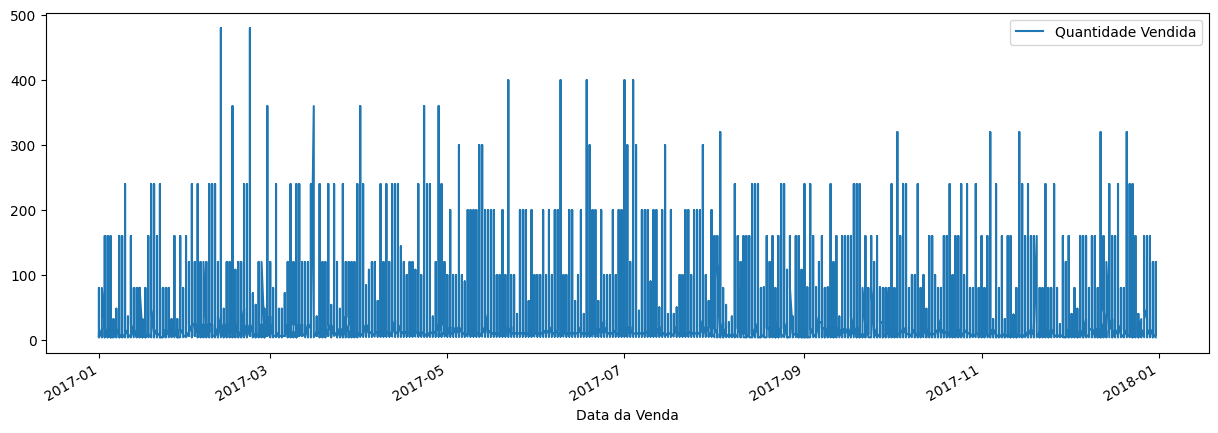

In [2]:
import matplotlib.pyplot as plt

tres_lojas_df.plot(x='Data da Venda', y='Quantidade Vendida', figsize=(15, 5))
plt.show()